# Endo-FM smoke test on ORena FOCUS PROCEDURE-track videos

Verifies the Endo-FM backbone runs end-to-end on the videos pulled by
`download_orena_procedure.ipynb` (`heico-focus-vqa` / `lapchole-focus-vqa`,
up to 5 videos total). **Not a benchmark** -- no labels are attached to
these videos yet, only raw video. Pairing them with the VQA question/answer
parquet data (a separate, not-yet-pulled step) would be needed before a real
downstream-task benchmark like the Cholec80/PitVis/Kvasir-Capsule notebooks
is possible here.

Unlike those notebooks (which replicate a single still frame across Endo-FM's
8-frame temporal window because they only had labeled *frames*), this one
has real video, so it samples genuine consecutive-frame clips -- an actual
test of the model's temporal pathway, not just its spatial one.

## 0. Setup

In [2]:

import sys, subprocess, random, json
from pathlib import Path

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE_ROOT = Path("/content/drive/MyDrive")
    PROJECT_ROOT = DRIVE_ROOT / "endofm-benchmark"
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "einops", "timm", "gdown", "opencv-python-headless"], check=True)
else:
    DRIVE_ROOT = None
    PROJECT_ROOT = Path(r"E:/endofm-benchmark")

ENDOFM_REPO = PROJECT_ROOT / "Endo-FM"
CKPT_DIR = PROJECT_ROOT / "checkpoints"
RESULTS_DIR = PROJECT_ROOT / "results" / "orena-procedure"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(ENDOFM_REPO))

import torch
print("torch:", torch.__version__, "| CUDA:", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random.seed(0)
torch.manual_seed(0)


Mounted at /content/drive
torch: 2.11.0+cpu | CUDA: False


## 1. Backbone

In [3]:

if not (ENDOFM_REPO / "models" / "timesformer.py").exists():
    subprocess.run(["git", "clone", "--depth", "1", "https://github.com/med-air/Endo-FM.git", str(ENDOFM_REPO)], check=True)

CKPT_PATH = CKPT_DIR / "endo_fm.pth"
if not CKPT_PATH.exists():
    import gdown
    gdown.download(id="1H7B91Ewm4QkZRsnUk1Bn0IQch5P8C7Xl", output=str(CKPT_PATH), quiet=False)


## 2. Discover downloaded orena-procedure videos

`download_orena_procedure.ipynb` writes videos to `PROJECT_ROOT/data/orena-procedure/<repo>/videos`,
**except** it skips re-downloading heico if it finds 5+ videos already sitting in a separate
Drive folder (`MyDrive/Debjyoti/orena-procedure/heico-focus-vqa/videos`) -- so this searches
both locations rather than assuming one.

In [4]:

VIDEO_EXTS = (".mp4", ".avi", ".mov", ".mkv")

candidate_dirs = [
    PROJECT_ROOT / "data" / "orena-procedure" / "heico-focus-vqa" / "videos",
    PROJECT_ROOT / "data" / "orena-procedure" / "lapchole-focus-vqa" / "videos",
]
if IN_COLAB:
    candidate_dirs.append(DRIVE_ROOT / "Debjyoti" / "orena-procedure" / "heico-focus-vqa" / "videos")

video_paths = []
seen = set()
for d in candidate_dirs:
    if not d.is_dir():
        continue
    for p in sorted(d.iterdir()):
        if p.suffix.lower() in VIDEO_EXTS and p.name not in seen:
            video_paths.append(p)
            seen.add(p.name)

if not video_paths:
    raise FileNotFoundError(
        "No orena-procedure videos found in any candidate directory: "
        + ", ".join(str(d) for d in candidate_dirs)
        + " -- run download_orena_procedure.ipynb first."
    )

print(f"Found {len(video_paths)} video(s):")
for p in video_paths:
    print(f"  {p}  ({p.stat().st_size / 1e6:.1f} MB)")


Found 5 video(s):
  /content/drive/MyDrive/Debjyoti/orena-procedure/heico-focus-vqa/videos/0000 - Heico - Prokto - 1.avi  (7428.0 MB)
  /content/drive/MyDrive/Debjyoti/orena-procedure/heico-focus-vqa/videos/0001 - Heico - Prokto - 2.avi  (7638.3 MB)
  /content/drive/MyDrive/Debjyoti/orena-procedure/heico-focus-vqa/videos/0002 - Heico - Prokto - 3.avi  (5173.7 MB)
  /content/drive/MyDrive/Debjyoti/orena-procedure/heico-focus-vqa/videos/0003 - Heico - Prokto - 4.avi  (3855.5 MB)
  /content/drive/MyDrive/Debjyoti/orena-procedure/heico-focus-vqa/videos/0004 - Heico - Prokto - 5.avi  (5464.9 MB)


## 3. Model

In [5]:

from models.timesformer import get_vit_base_patch16_224

class SimpleCfg:
    class DATA:
        TRAIN_CROP_SIZE = 224
        NUM_FRAMES = 8
    class MODEL:
        NUM_CLASSES = 0
    class TIMESFORMER:
        ATTENTION_TYPE = "divided_space_time"
        PRETRAINED_MODEL = ""

def build_backbone(load_checkpoint: bool):
    model = get_vit_base_patch16_224(cfg=SimpleCfg(), no_head=True)
    if load_checkpoint:
        ckpt = torch.load(CKPT_PATH, map_location="cpu", weights_only=False)
        if "teacher" in ckpt:
            ckpt = ckpt["teacher"]
        state_dict = {k[len("backbone."):]: v for k, v in ckpt.items() if k.startswith("backbone.")}
        msg = model.load_state_dict(state_dict, strict=False)
        print("Loaded Endo-FM weights:", msg)
    model.eval().to(DEVICE)
    return model

NUM_FRAMES = SimpleCfg.DATA.NUM_FRAMES
IMG_SIZE = SimpleCfg.DATA.TRAIN_CROP_SIZE
model = build_backbone(load_checkpoint=True)


/usr/local/lib/python3.13/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Loaded Endo-FM weights: <All keys matched successfully>


## 4. Sample real temporal clips per video

For each video, grabs `CLIPS_PER_VIDEO` windows of `NUM_FRAMES` **consecutive**
decoded frames (start positions spread evenly across the video, skipping a
`EDGE_MARGIN_FRAC` margin at each end in case of black/title frames), via a
single sequential decode per video -- no re-seeking.

In [6]:

import cv2

CLIPS_PER_VIDEO = 3
EDGE_MARGIN_FRAC = 0.05

def sample_clip_starts(n_frames, n_clips, num_frames, edge_margin_frac):
    lo = int(n_frames * edge_margin_frac)
    hi = n_frames - int(n_frames * edge_margin_frac) - num_frames
    if hi <= lo:
        return [max(0, n_frames - num_frames)]
    return [int(round(lo + i * (hi - lo) / max(1, n_clips - 1))) for i in range(n_clips)]

def extract_clips(video_path, n_clips, num_frames):
    cap = cv2.VideoCapture(str(video_path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    if total <= 0:
        cap.release()
        return [], fps
    starts = sample_clip_starts(total, n_clips, num_frames, EDGE_MARGIN_FRAC)
    wanted = {start + i for start in starts for i in range(num_frames)}
    frames_by_idx = {}
    idx, target_max = 0, max(wanted)
    while idx <= target_max:
        ok, frame = cap.read()
        if not ok:
            break
        if idx in wanted:
            frames_by_idx[idx] = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        idx += 1
    cap.release()
    clips = []
    for start in starts:
        frames = [frames_by_idx[start + i] for i in range(num_frames) if (start + i) in frames_by_idx]
        if len(frames) == num_frames:
            clips.append((start, frames))
    return clips, fps

video_clips = []  # (video_path, clip_start_frame, fps, [RGB ndarray x NUM_FRAMES])
for video_path in video_paths:
    clips, fps = extract_clips(video_path, CLIPS_PER_VIDEO, NUM_FRAMES)
    print(f"{video_path.name}: fps={fps:.1f}, got {len(clips)}/{CLIPS_PER_VIDEO} clips")
    for start, frames in clips:
        video_clips.append((video_path, start, fps, frames))

print(f"\nTotal clips across all videos: {len(video_clips)}")


0000 - Heico - Prokto - 1.avi: fps=25.0, got 3/3 clips
0001 - Heico - Prokto - 2.avi: fps=25.0, got 3/3 clips
0002 - Heico - Prokto - 3.avi: fps=25.0, got 3/3 clips
0003 - Heico - Prokto - 4.avi: fps=25.0, got 3/3 clips
0004 - Heico - Prokto - 5.avi: fps=25.0, got 3/3 clips

Total clips across all videos: 15


## 5. Preprocess clips + run the backbone

In [7]:

import numpy as np
from PIL import Image
import torchvision.transforms as T

preprocess = T.Compose([
    T.Resize(256),
    T.CenterCrop(IMG_SIZE),
    T.ToTensor(),
    T.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

def clip_to_tensor(frames):
    # (T, C, H, W) -> (C, T, H, W), matching the model's expected clip layout
    per_frame = [preprocess(Image.fromarray(f)) for f in frames]
    return torch.stack(per_frame, dim=1)

@torch.no_grad()
def run_backbone_on_clips(video_clips, batch_size=4):
    feats = []
    for i in tqdm(range(0, len(video_clips), batch_size), desc="Feature extraction"):
        batch = video_clips[i:i + batch_size]
        x = torch.stack([clip_to_tensor(frames) for _, _, _, frames in batch]).to(DEVICE)
        f = model(x)
        feats.append(f.cpu().numpy())
    return np.concatenate(feats) if feats else np.zeros((0, 768))

from tqdm.auto import tqdm

features = run_backbone_on_clips(video_clips)
print("Feature matrix shape:", features.shape)
assert features.shape == (len(video_clips), 768), "unexpected feature shape -- pipeline is broken"
print("PASS: model loads, forward pass runs on real video clips, output shape is correct.")


Feature extraction:   0%|          | 0/4 [00:00<?, ?it/s]

Feature matrix shape: (15, 768)
PASS: model loads, forward pass runs on real video clips, output shape is correct.


## 6. Qualitative sanity check (not a benchmark -- no labels exist for this data yet)

With no downstream labels, the only thing worth checking is whether the
representation is doing *anything* sensible: clips from the **same** video
should generally be more similar to each other (cosine similarity) than
clips from **different** videos, since consecutive/nearby surgical footage
shares scene content. This is a plausibility check, not an accuracy number.

In [8]:

def cosine_sim_matrix(feats):
    norm = feats / (np.linalg.norm(feats, axis=1, keepdims=True) + 1e-8)
    return norm @ norm.T

sim = cosine_sim_matrix(features)
video_names = [vp.name for vp, _, _, _ in video_clips]

same_video_sims, diff_video_sims = [], []
for i in range(len(video_clips)):
    for j in range(i + 1, len(video_clips)):
        (same_video_sims if video_names[i] == video_names[j] else diff_video_sims).append(sim[i, j])

print(f"Same-video clip-pair cosine similarity:      mean={np.mean(same_video_sims):.3f}  n={len(same_video_sims)}")
print(f"Different-video clip-pair cosine similarity:  mean={np.mean(diff_video_sims):.3f}  n={len(diff_video_sims)}")
print("(same-video should generally read higher; if not, that's worth a closer look, not proof of a bug --"
      " these are different colorectal/lap-chole procedures that may just look visually similar to each other too)")


Same-video clip-pair cosine similarity:      mean=0.550  n=15
Different-video clip-pair cosine similarity:  mean=0.510  n=90
(same-video should generally read higher; if not, that's worth a closer look, not proof of a bug -- these are different colorectal/lap-chole procedures that may just look visually similar to each other too)


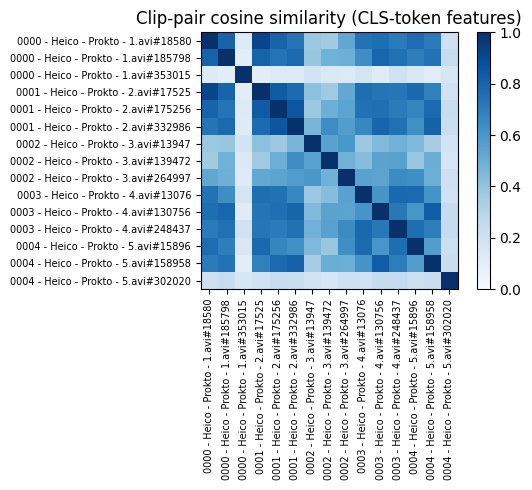

In [9]:

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(sim, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(video_clips))); ax.set_xticklabels(
    [f"{n}#{s}" for n, (_, s, _, _) in zip(video_names, video_clips)], rotation=90, fontsize=7)
ax.set_yticks(range(len(video_clips))); ax.set_yticklabels(
    [f"{n}#{s}" for n, (_, s, _, _) in zip(video_names, video_clips)], fontsize=7)
ax.set_title("Clip-pair cosine similarity (CLS-token features)")
fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "clip_similarity_matrix.png", dpi=150)
plt.show()


## 7. Save features (for reuse once a real downstream task/labels exist)

In [10]:

np.save(RESULTS_DIR / "smoketest_features.npy", features)

manifest = [
    {"video": str(vp), "clip_start_frame": start, "fps": fps}
    for vp, start, fps, _ in video_clips
]
with open(RESULTS_DIR / "smoketest_clip_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

print("Saved:", RESULTS_DIR / "smoketest_features.npy", features.shape)
print("Saved:", RESULTS_DIR / "smoketest_clip_manifest.json")


Saved: /content/drive/MyDrive/endofm-benchmark/results/orena-procedure/smoketest_features.npy (15, 768)
Saved: /content/drive/MyDrive/endofm-benchmark/results/orena-procedure/smoketest_clip_manifest.json


## Summary

In [11]:

print("Smoke test passed:" if features.shape[1] == 768 else "Smoke test FAILED:")
print(f"  videos found: {len(video_paths)}")
print(f"  clips extracted: {len(video_clips)}")
print(f"  feature dim: {features.shape[1]}")
print("This confirms the backbone runs end-to-end on real orena-procedure video clips.")
print("It is NOT a benchmark -- that needs labels (e.g. the VQA parquet data, not yet pulled/parsed).")


Smoke test passed:
  videos found: 5
  clips extracted: 15
  feature dim: 768
This confirms the backbone runs end-to-end on real orena-procedure video clips.
It is NOT a benchmark -- that needs labels (e.g. the VQA parquet data, not yet pulled/parsed).
